In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
adata_tfa=sc.read_h5ad("out/stf_results_tfa_only.h5ad")
adata_raw=sc.read_h5ad("data/visium_lymph_node.h5ad")
adata_tfa.layers['gex']=adata_raw.to_df().loc[adata_tfa.obs_names,adata_tfa.var_names]

In [2]:
adata_tfa

AnnData object with n_obs × n_vars = 3989 × 234
    obs: 'in_tissue', 'array_row', 'array_col', 'germinal_center', 'n_counts', 'ncounts', 'pixel_intensity', 'pred_cor_stl', 'pred_cor_stan'
    uns: 'spatial', 'tf_names'
    obsm: 'celltype', 'celltype_raw', 'kernel', 'pixel_intensity', 'spatial'
    layers: 'stan_tfa', 'stl_tfa', 'gex'

In [3]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
from statsmodels.stats.multitest import multipletests

ct_tf_df=[]
A=adata_tfa.obsm['celltype'].copy()
# A=A*((A>0.05)+0)
Y=adata_tfa.to_df()
Y=Y-Y.mean()
Y=Y/Y.std()
for tf in adata_tfa.var_names:
    y=Y[tf]

    results = sm.OLS(y,A).fit()
    for ct in A.columns:
        p=results.pvalues[ct]
        coef=results.params[ct]
        se=results.bse[ct]
        ct_tf_df.append([tf, ct, coef, p, se, results.rsquared])

ct_tf_df=pd.DataFrame(ct_tf_df, columns=["tf", "ct", "coef", "p",'SE', 'r_squared'])
ct_tf_df=ct_tf_df.sort_values(by=['tf', 'ct'])
ct_tf_df["p_adj"]=multipletests(ct_tf_df['p'], alpha=0.01, method="fdr_bh")[1]
ct_tf_df["negative_log_p_adj"]=-np.log10(ct_tf_df["p_adj"]+1e-10)
#ct_tf_df.to_csv('cell_type_scores.csv')

In [4]:
ct_tf_df

,tf,ct,coef,p,SE,r_squared,p_adj,negative_log_p_adj
0,AHR,B_Cycling,-5.346650,6.817148e-12,0.776865,0.162121,1.628746e-10,9.580251
1,AHR,B_GC_DZ,3.037188,1.184973e-01,1.945105,0.162121,2.333254e-01,0.632038
2,AHR,B_GC_LZ,-1.070857,3.400265e-01,1.122223,0.162121,5.027412e-01,0.298656
3,AHR,B_GC_prePB,3.976814,2.693406e-01,3.599782,0.162121,4.270673e-01,0.369504
4,AHR,B_IFN,-2.447805,3.017478e-06,0.523442,0.162121,2.724978e-05,4.564635
...,...,...,...,...,...,...,...,...
7951,ZNF84,T_CD8+_naive,1.540584,6.262349e-01,3.162956,0.290069,7.543263e-01,0.122441
7952,ZNF84,T_TIM3+,1.368430,1.825575e-01,1.026459,0.290069,3.215388e-01,0.492767
7953,ZNF84,T_TfR,-0.209262,9.278159e-01,2.309762,0.290069,9.577921e-01,0.018729
7954,ZNF84,T_Treg,1.696584,3.739199e-01,1.907870,0.290069,5.339029e-01,0.272538


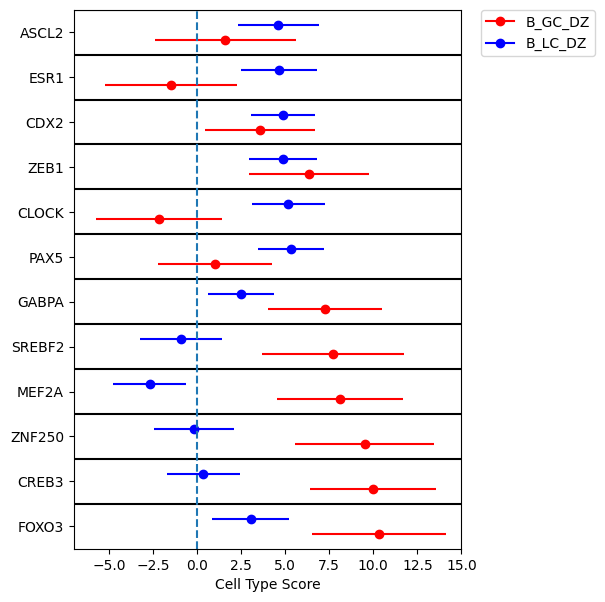

In [5]:
tfs=ct_tf_df.query("(ct=='B_GC_DZ' or ct=='B_GC_LZ') and p_adj <0.001").sort_values('coef', ascending=False).head(12)['tf'].to_list()
plt.figure(figsize=(5,7))
i=0
ticks=[]
labels=[]
for tf in tfs:


    ticks.append(i+0.5)
    labels.append(tf)

    coef=ct_tf_df.query("ct=='B_GC_DZ' and tf==@tf")['coef']
    se=ct_tf_df.query("ct=='B_GC_DZ' and tf==@tf")['SE']
    plt.errorbar(coef, i, yerr=None, xerr=2*se, color='r')
    plt.plot(coef,i, 'o', color='r')
    i=i+1
    coef=ct_tf_df.query("ct=='B_GC_LZ' and tf==@tf")['coef']
    se=ct_tf_df.query("ct=='B_GC_LZ' and tf==@tf")['SE']
    plt.errorbar(coef, i, yerr=None, xerr=2*se, color='b')
    plt.plot(coef,i, 'o', color='b')
    # ticks.append(i)
    # labels.append(tf+" LZ")

    i=i+1
    plt.hlines(i, -20,20, color='black')
    i=i+1

plt.yticks(ticks, labels)
plt.xlim(-7,15)
plt.vlines(0,-1,  i+3, colors=None, linestyles='dashed')
plt.ylim(-1,i-1)
plt.xlabel("Cell Type Score")

plt.plot([-10,-10], [-11,-11], 'o-',label='B_GC_DZ', color='r')
plt.plot([-10,-10], [-11,-11], 'o-',label='B_LC_DZ', color='b')
plt.legend(bbox_to_anchor=(1.05,1),
           loc='upper left',
           borderaxespad=0)


In [6]:
ct_tf_df.query("ct=='B_GC_DZ' and tf==@tf")['coef']

205    1.592651
Name: coef, dtype: float64

In [7]:
adata_tfa.obsm['celltype']

,B_Cycling,B_GC_DZ,B_GC_LZ,B_GC_prePB,B_IFN,B_activated,B_mem,B_naive,B_plasma,B_preGC,...,T_CD4+_TfH,T_CD4+_TfH_GC,T_CD4+_naive,T_CD8+_CD161+,T_CD8+_cytotoxic,T_CD8+_naive,T_TIM3+,T_TfR,T_Treg,VSMC
AAACAAGTATCTCCCA-1,0.014304,0.004291,0.009838,0.001631,0.007460,0.058387,0.066087,0.176268,0.071517,0.034278,...,0.022072,0.008777,0.099347,0.014532,0.024978,0.027564,0.053307,0.011292,0.023694,0.023908
AAACAATCTACTAGCA-1,0.010970,0.003140,0.003121,0.010249,0.023918,0.002999,0.004663,0.006454,0.007097,0.029351,...,0.020164,0.010402,0.460768,0.009193,0.027489,0.054988,0.038013,0.033988,0.060476,0.019545
AAACACCAATAACTGC-1,0.016023,0.004800,0.007748,0.002735,0.002764,0.053791,0.115564,0.104310,0.035633,0.065812,...,0.015546,0.009021,0.056641,0.010446,0.024629,0.014912,0.059203,0.007736,0.010822,0.022477
AAACAGAGCGACTCCT-1,0.024432,0.005082,0.009965,0.004315,0.368534,0.002072,0.001441,0.005292,0.007063,0.030701,...,0.009410,0.007992,0.152817,0.006901,0.031141,0.021395,0.054518,0.019565,0.030137,0.010812
AAACAGCTTTCAGAAG-1,0.004670,0.004172,0.010534,0.002318,0.009373,0.037803,0.253315,0.294039,0.010730,0.057246,...,0.006667,0.018914,0.092688,0.003240,0.006798,0.007088,0.017947,0.006130,0.007050,0.006954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTTTCACATCCAGG-1,0.008617,0.003978,0.007782,0.003607,0.004069,0.053519,0.142002,0.158318,0.045137,0.040294,...,0.015320,0.013886,0.079771,0.010524,0.021998,0.016731,0.055433,0.014894,0.012433,0.025542
TTGTTTCATTAGTCTA-1,0.014788,0.002913,0.005017,0.001996,0.002440,0.045792,0.140145,0.107977,0.032119,0.046259,...,0.017710,0.012276,0.062642,0.010510,0.016900,0.012852,0.050142,0.009706,0.010856,0.029765
TTGTTTCCATACAACT-1,0.001765,0.003178,0.027848,0.004947,0.010099,0.041780,0.086612,0.180795,0.014404,0.023102,...,0.018138,0.017746,0.094264,0.011122,0.029515,0.022879,0.041244,0.011066,0.030710,0.024468
TTGTTTGTATTACACG-1,0.002922,0.003537,0.003682,0.003242,0.028644,0.009158,0.050947,0.021215,0.013164,0.031839,...,0.019437,0.006571,0.362208,0.011556,0.038335,0.047803,0.041751,0.048171,0.071793,0.016000


In [8]:
coef_mat=ct_tf_df.pivot(index="ct", columns='tf', values='coef')

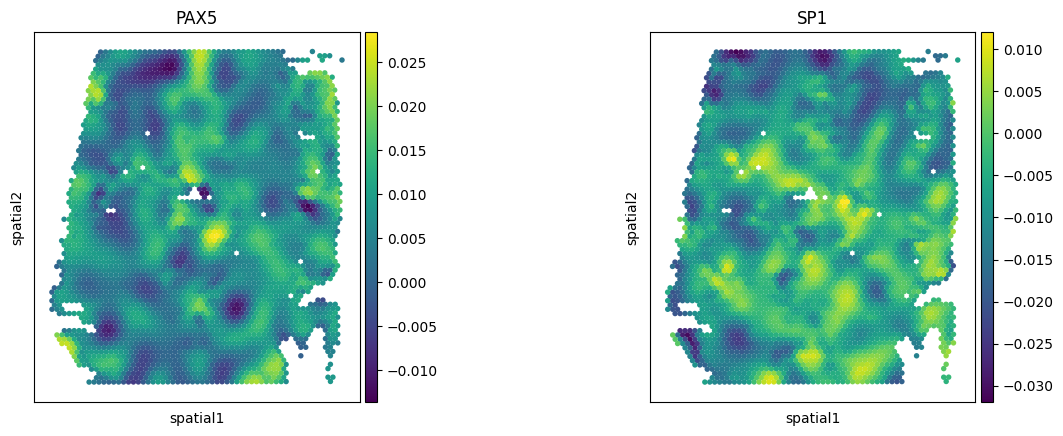

NameError: name 'sq' is not defined

In [9]:
sc.pl.spatial(adata_tfa, color=['PAX5', "SP1"], size=1.7, alpha_img=0)
sc.pl.spatial(sq.pl.extract(adata_tfa, "celltype"),color=['B_GC_LZ', "B_GC_DZ"], size=1.7, alpha_img=0)

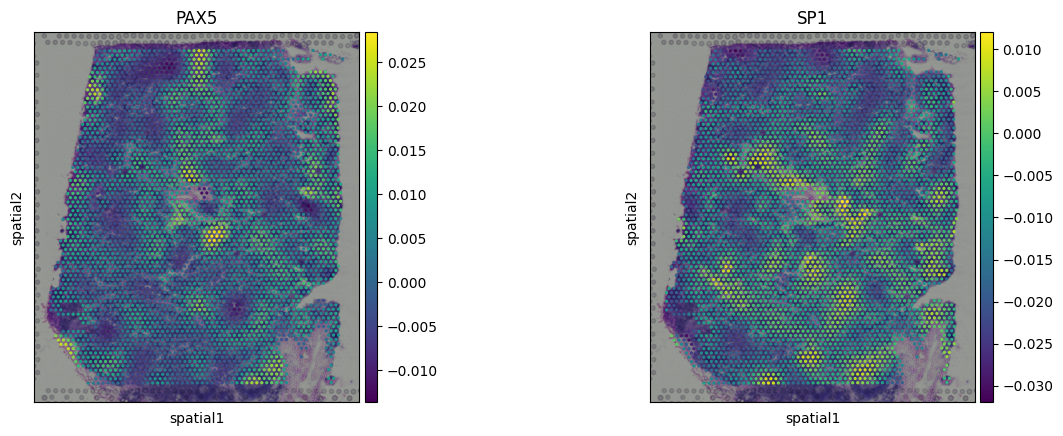

In [10]:
sc.pl.spatial(adata_tfa, color=['PAX5', "SP1"])

In [13]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
def dotplot(data, x, y, color, size, sizes=(0,50), colors=(-0.5,0.5), dpi=300):
    #normalize = mcolors.TwoSlopeNorm(vcenter=0, vmin=colors[0], vmax=colors[1])
    # colormap = cm.PiYG
    if colors:
        data[color]=data[color].clip(colors[0], colors[1])





    data[x]=data[x].astype("category")
    data[y]=data[y].astype("category")

    x_lab=data[x].cat.categories
    y_lab=data[y].cat.categories

    f=sns.clustermap(data.pivot(index=y, columns=x, values=color),figsize=(0.1,0.1), cmap='PiYG')

    x_lab=x_lab[f.dendrogram_col.reordered_ind]
    y_lab=y_lab[f.dendrogram_row.reordered_ind]


    data[x]=data[x].cat.reorder_categories(x_lab)
    data[y]=data[y].cat.reorder_categories(y_lab)
    data=data.sort_values([x, y])


    plt.figure(figsize=(0.15*len(x_lab),0.15*len(y_lab)), dpi=dpi)

    ax =sns.scatterplot(data=data,
                        y=y,
                        x=x,
                        hue=color,
                        palette="PiYG",
                        size=size,
                        sizes=sizes)

    ax.set_xlim(-0.5, -0.5+len(x_lab))
    ax.set_ylim(-0.5, -0.5+len(y_lab))

    ax.set_xticklabels(x_lab,rotation = 90)
    plt.legend(bbox_to_anchor=(1.05,1),
               loc='upper left',
               borderaxespad=0)
    return ax
plt.rcParams['pdf.fonttype']=42
plt.rcParams.update({'font.sans-serif':'Helvetica'})
plt.rcParams.update({'font.size':7})

/var/folders/t6/876nj23922g7ync9x5slmd0h0000gq/T/ipykernel_61048/3021487190.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[color]=data[color].clip(colors[0], colors[1])
/var/folders/t6/876nj23922g7ync9x5slmd0h0000gq/T/ipykernel_61048/3021487190.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[x]=data[x].astype("category")
/var/folders/t6/876nj23922g7ync9x5slmd0h0000gq/T/ipykernel_61048/3021487190.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

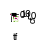

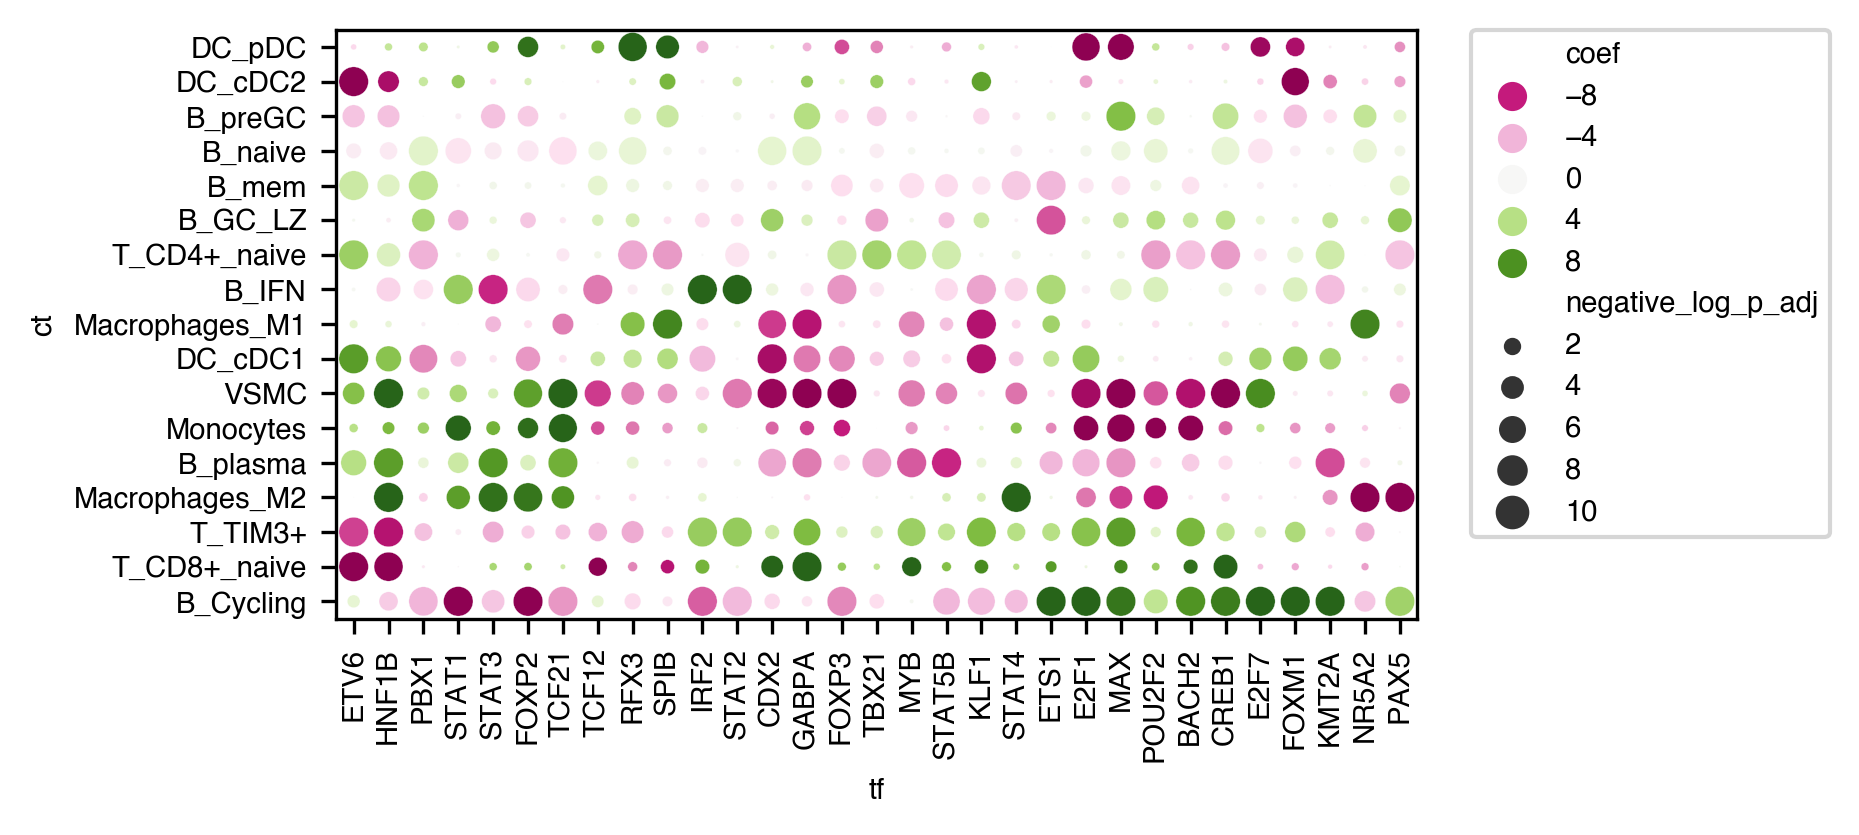

In [24]:
filtered_df=ct_tf_df.query("negative_log_p_adj>9 and r_squared >0.4")
tfs=filtered_df['tf'].unique()
cts=filtered_df['ct'].unique()
df=ct_tf_df.query("tf in @tfs and ct in @cts")

# df['tf']=df['tf'].astype("category")
# df['ct']=df['ct'].astype("category")


# f=sns.clustermap(coef_mat.loc[cts, tfs],figsize=(1,1))


# df['tf']=df['tf'].cat.reorder_categories(tfs[f.dendrogram_col.reordered_ind])
# df['ct']=df['ct'].cat.reorder_categories(cts[f.dendrogram_row.reordered_ind])
#df=df.sort_values(['tf', 'ct'])
#sns.set_style("ticks", {'axes.edgecolor': 'white'})
ax=dotplot(data=df,
        x="tf", y="ct", color="coef", size="negative_log_p_adj",
        colors=(-10,10))
plt.savefig("figures/cell_type_score_dotplot_r4.pdf", bbox_inches='tight', pad_inches=0)

In [25]:
A=adata_tfa.obsm['celltype'].copy()
A=(A-A.mean())/A.std()

Y=adata_tfa.to_df("stan_tfa")
Y=Y-Y.mean()
Y=Y/Y.std()
cor_mat=Y.T.dot(A)/adata_tfa.n_obs

Y=adata_tfa.to_df("stl_tfa")
Y=Y-Y.mean()
Y=Y/Y.std()
stl_cor_mat=Y.T.dot(A)/adata_tfa.n_obs


Y=np.log1p(adata_tfa.to_df("gex"))
Y=Y-Y.mean()
Y=Y/Y.std()
gex_mat=Y.T.dot(A)/adata_tfa.n_obs


Top celltype for each TF (cuttoff: $r>0.5$):

,0,1,2
0,B_Cycling,E2F1,0.663841
1,B_GC_DZ,FOXM1,0.47071
2,B_GC_LZ,CREB1,0.552684
3,B_GC_prePB,E2F1,0.513139
4,B_IFN,STAT2,0.797493
5,B_activated,ETV4,0.477807
6,B_mem,ETV6,0.523193
7,B_naive,PBX1,0.578251
8,B_plasma,STAT3,0.479688
9,B_preGC,GTF2B,0.239276


array([['B_Cycling', 'E2F1', 0.6638414238997219],
       ['B_GC_DZ', 'FOXM1', 0.4707096696484327],
       ['B_GC_LZ', 'CREB1', 0.552684086877931],
       ['B_GC_prePB', 'E2F1', 0.5131386788057254],
       ['B_activated', 'ETV4', 0.47780703264435986],
       ['B_naive', 'PBX1', 0.578251260567234],
       ['B_plasma', 'STAT3', 0.47968763125195607]], dtype=object)

In [85]:
cta=adata_tfa.obsm['celltype'].quantile(0.95)
cta.name='cta'
df=plot_list.join(cta)

In [86]:
df

,index,value,cta
variable,,,
B_Cycling,E2F1,0.663841,0.117622
B_GC_DZ,FOXM1,0.470710,0.025200
B_GC_LZ,CREB1,0.552684,0.096773
B_GC_prePB,E2F1,0.513139,0.028661
B_IFN,STAT2,0.797493,0.042026
B_activated,ETV4,0.477807,0.065607
B_mem,ETV6,0.523193,0.243694
B_naive,PBX1,0.578251,0.296632
B_plasma,STAT3,0.479688,0.089804


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


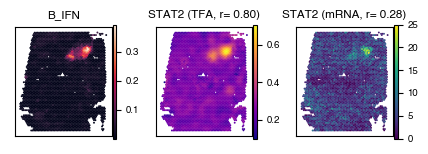

In [58]:
plt.rcParams['pdf.fonttype']=42
plt.rcParams.update({'font.sans-serif':'Helvetica'})
plt.rcParams.update({'font.size':7})

ct1="B_IFN"
tf="STAT2"
fig, axs=plt.subplots(1,3, figsize=(4.3,1.5))
sc.pl.spatial(sq.pl.extract(adata_tfa, "celltype"),
              color=ct1, alpha_img=0, ax=axs[0],show=False, cmap="rocket", size=2,
              title=ct1)

sc.pl.spatial(adata_tfa, color=tf, alpha_img=0, ax=axs[1],show=False, cmap="plasma", size=2, title=tf+" (TFA, r= %.2f)"% cor_mat.loc[tf, ct1])

sc.pl.spatial(adata_tfa, color=tf, layer='gex', alpha_img=0, ax=axs[2],show=False, cmap="viridis", size=2, title=tf+" (mRNA, r= %.2f)"% gex_mat.loc[tf, ct1])

for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/Bifn_stat2.pdf", bbox_inches='tight', pad_inches=0)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


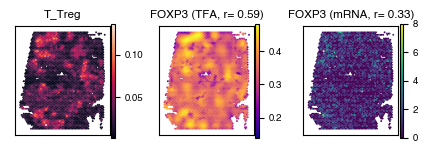

In [59]:
ct1="T_Treg"
tf="FOXP3"
fig, axs=plt.subplots(1,3, figsize=(4.33,1.5))
sc.pl.spatial(sq.pl.extract(adata_tfa, "celltype"),
              color=ct1, alpha_img=0, ax=axs[0],show=False, cmap="rocket", size=2,
              title=ct1)

sc.pl.spatial(adata_tfa, color=tf, alpha_img=0, ax=axs[1],show=False, cmap="plasma", size=2, title=tf+" (TFA, r= %.2f)"% cor_mat.loc[tf, ct1])

sc.pl.spatial(adata_tfa, color=tf, layer='gex', alpha_img=0, ax=axs[2],show=False, cmap="viridis", size=2, title=tf+" (mRNA, r= %.2f)"% gex_mat.loc[tf, ct1])

for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/Treg_foxp3.pdf", bbox_inches='tight', pad_inches=0)

Top celltype for each TF (cuttoff: $r>0.5$): 

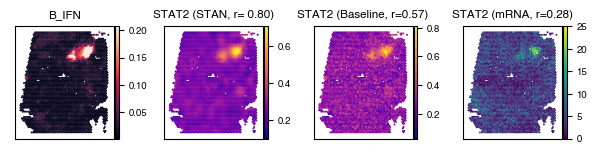

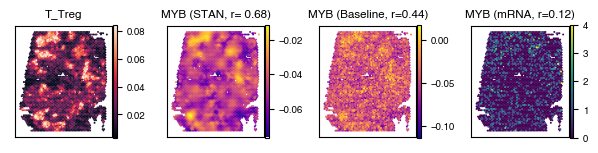

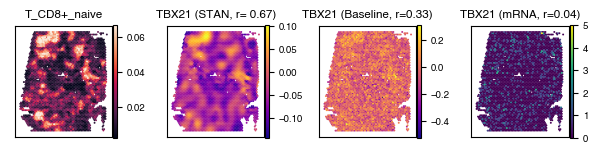

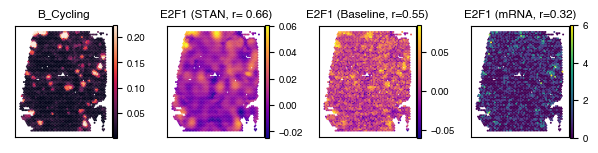

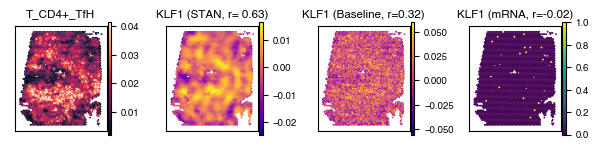

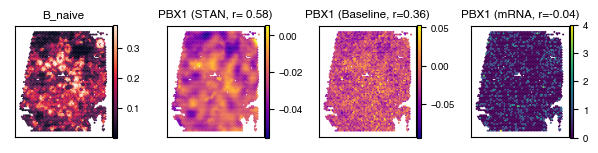

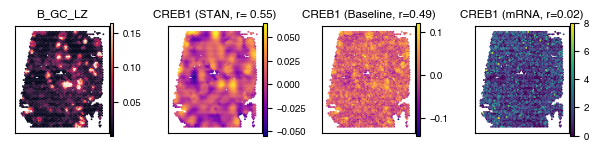

In [98]:
import matplotlib
plt.rcParams['pdf.fonttype']=42
plt.rcParams.update({'font.sans-serif':'Helvetica'})
plt.rcParams.update({'font.size':7})

tf_vmin=adata_tfa.to_df().quantile(0.01)
tf_vmax=adata_tfa.to_df().quantile(0.99)
ct_vmin=adata_tfa.obsm['celltype'].quantile(0.01)
ct_vmax=adata_tfa.obsm['celltype'].quantile(0.99)

plot_list=cor_mat.reset_index().melt(id_vars='index').sort_values('value', ascending=False).groupby("variable").first().reset_index().sort_values("value", ascending=False).to_numpy()
plot_list=plot_list[[0,1,2,3,5,7,8],:]
for ct1,tf, v in plot_list:
    # ct1=ct_tf_df.query("tf==@tf and coef>0").sort_values("p_adj").head(2)['ct'].to_list()[0]
    # ct1_score=ct_tf_df.query("tf==@tf and coef>0").sort_values("p_adj").head(2)['coef'].to_list()[0]
    # ct2=ct_tf_df.query("tf==@tf and coef>0").sort_values("p_adj").head(2)['ct'].to_list()[1]
    # ct2_score=ct_tf_df.query("tf==@tf and coef>0").sort_values("p_adj").head(2)['coef'].to_list()[1]

    fig, axs=plt.subplots(1,4, figsize=(6,1.5))
    sc.pl.spatial(sq.pl.extract(adata_tfa, "celltype"),
                  color=ct1, alpha_img=0, ax=axs[0],show=False, cmap="rocket", size=2,
                  title=ct1,
                  vmin=ct_vmin.loc[ct1], vmax=ct_vmax.loc[ct1]
                  )
    # sc.pl.spatial(sq.pl.extract(adata_tfa, "celltype"),
    #               color=ct2, alpha_img=0, ax=axs[3],show=False, cmap="inferno", size=1.5,
    #               title="%s (score: %.2f)"%(ct2, ct2_score)
    #               )
    sc.pl.spatial(adata_tfa, color=tf, alpha_img=0, ax=axs[1],show=False, cmap="plasma", size=2, title=tf+" (STAN, r= %.2f)"%v )
    sc.pl.spatial(adata_tfa, color=tf, alpha_img=0, ax=axs[2],show=False, cmap="plasma", size=2, layer='stl_tfa',title=tf+" (Baseline, r=%.2f)"% stl_cor_mat.loc[tf, ct1])
    sc.pl.spatial(adata_tfa, color=tf, layer='gex', alpha_img=0, ax=axs[3],show=False, cmap="viridis", size=2, title=tf+" (mRNA, r=%.2f)"% gex_mat.loc[tf, ct1])

    # sc.pl.spatial(adata_tfa, color=tf, layer='stl_tfa', alpha_img=0, ax=axs[1],show=False, cmap="plasma", size=1.5, title=tf+" (Ridge Regression)")

    for ax in axs:
        ax.set_xlabel("")
        ax.set_ylabel("")
    plt.tight_layout()